# MERIDIAN - Analysis Module 8: Anomaly / Fraud Flagging (Lite)

## Business question
Which individual orders look statistically unusual compared to what we'd normally expect - a simple first-pass filter worth a closer look.

## Important caveat, upfront
**This is illustrative, not production fraud detection.** A real fraud system uses many signals together (device fingerprints, IP geolocation, payment method mismatches, velocity checks, etc.). This notebook uses a single signal - how far an order's value sits from what's 'normal' for that customer - which is a reasonable starting filter, not a verdict. A flagged order should be reviewed by a person, not auto-blocked.

## Method: leave-one-out z-scores
For each order, compute how many standard deviations it sits from the customer's *own* typical order value - using that customer's OTHER orders only, not including the order being evaluated. This detail matters: a first attempt at this notebook included the order itself when computing the customer's average, which let a genuine $500 outlier against a $48-55 pattern go undetected - the outlier inflated its own comparison baseline enough to mask itself (a well-known problem called 'outlier masking'). Excluding the order under review from its own baseline fixes this. Verified against a hand-built test case before running on real data (see PROJECT_LOG.md).

## Fallback for thin history
Most customers only have 1-2 orders (see Module 3's repeat-purchase findings), so a customer-level baseline often isn't statistically meaningful. When a customer has fewer than 2 *other* orders, or zero variance among them, this falls back to comparing against the whole region's order-value distribution instead - documented explicitly per order, not silently.

## Step 1 - Connect and load order data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import pyodbc

def get_engine(server="localhost", database="MeridianDB"):
    available = pyodbc.drivers()
    preferred_order = [
        "ODBC Driver 18 for SQL Server",
        "ODBC Driver 17 for SQL Server",
        "ODBC Driver 13 for SQL Server",
        "SQL Server Native Client 11.0",
        "SQL Server",
    ]
    driver = next((d for d in preferred_order if d in available), None)
    if driver is None:
        raise RuntimeError("No SQL Server ODBC driver found. Install 'ODBC Driver 17 for SQL Server'.")
    conn_str = f"mssql+pyodbc://@{server}/{database}?driver={driver.replace(' ', '+')}&trusted_connection=yes"
    return create_engine(conn_str)

engine = get_engine()
orders = pd.read_sql("SELECT order_id, customer_id, region, amount_usd FROM marts.fct_orders", engine)
orders = orders.dropna(subset=['customer_id', 'amount_usd'])
print(f"{len(orders):,} orders with a valid customer and amount")

149,593 orders with a valid customer and amount


## Step 2 - Compute leave-one-out z-scores

Precomputes each customer's total, sum, and sum-of-squares once (fast), then derives the leave-one-out mean/std for each individual order algebraically, rather than recomputing from scratch per order - keeps this fast even across the full dataset.

**A second real bug was caught here, worth documenting.** An initial run produced z-scores in the hundreds of millions - clearly not real statistics. Root cause: a customer whose other orders happen to be tightly clustered (e.g. three orders within a few cents of each other) has an almost-zero standard deviation - not exactly zero (which was already guarded against), but small enough that dividing by it exploded even a completely ordinary next order into an absurd z-score. This is a classic near-zero-denominator problem. **Fix:** require a customer's own standard deviation to be at least 5% of the region's overall standard deviation before trusting it as a baseline - otherwise fall back to the region level, same as the existing thin-history fallback. Verified against a hand-built test case reproducing the exact failure before redeploying.

In [12]:
cust_agg = orders.groupby('customer_id')['amount_usd'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'n', 'sum': 'total', 'mean': 'cust_mean_all'})
cust_agg['sumsq'] = orders.groupby('customer_id')['amount_usd'].apply(lambda s: (s**2).sum())
orders = orders.join(cust_agg, on='customer_id')

n_others = orders['n'] - 1
loo_sum = orders['total'] - orders['amount_usd']
loo_mean = loo_sum / n_others.replace(0, np.nan)
loo_sumsq = orders['sumsq'] - orders['amount_usd']**2
loo_var = (loo_sumsq / n_others.replace(0, np.nan)) - loo_mean**2
loo_std = np.sqrt(loo_var.clip(lower=0))

region_stats = orders.groupby('region')['amount_usd'].agg(['mean', 'std']).rename(
    columns={'mean': 'region_mean', 'std': 'region_std'})
orders = orders.join(region_stats, on='region')

# A customer's own std must be at least 5% of their region's overall std
# to be trusted as a baseline - otherwise a near-zero denominator can
# explode an ordinary order into an absurd z-score (see markdown above).
MIN_STD_FRACTION = 0.05
min_trustworthy_std = MIN_STD_FRACTION * orders['region_std']

use_customer_baseline = (n_others >= 2) & (loo_std > min_trustworthy_std)
orders['baseline'] = np.where(use_customer_baseline, 'customer', 'region')
orders['z_score'] = np.where(
    use_customer_baseline,
    (orders['amount_usd'] - loo_mean) / loo_std,
    (orders['amount_usd'] - orders['region_mean']) / orders['region_std']
)

Z_THRESHOLD = 3
orders['flagged'] = orders['z_score'].abs() > Z_THRESHOLD

print(f"Baseline used: {orders['baseline'].value_counts().to_dict()}")
print(f"Flagged orders: {orders['flagged'].sum():,} out of {len(orders):,} ({orders['flagged'].mean():.2%})")
print(f"Max |z-score| after fix: {orders['z_score'].abs().max():.2f} (should be a normal-looking number, not millions)")

Baseline used: {'region': 106289, 'customer': 43304}
Flagged orders: 3,646 out of 149,593 (2.44%)
Max |z-score| after fix: 91.96 (should be a normal-looking number, not millions)


## Step 3 - Look at what got flagged, by region

In [13]:
flag_summary = orders.groupby('region')['flagged'].agg(['sum', 'count'])
flag_summary['flag_rate_pct'] = (flag_summary['sum'] / flag_summary['count'] * 100).round(2)
flag_summary.columns = ['flagged_count', 'total_orders', 'flag_rate_pct']
flag_summary.sort_values('flag_rate_pct', ascending=False)

,flagged_count,total_orders,flag_rate_pct
region,,,
GH,250,2016,12.40
US,240,2018,11.89
DE,235,2017,11.65
UK,1128,44876,2.51
BR,1793,98666,1.82


In [14]:
top_flagged = orders[orders['flagged']].sort_values('z_score', key=abs, ascending=False).head(15)
top_flagged[['order_id', 'region', 'amount_usd', 'baseline', 'z_score']].round(2)

,order_id,region,amount_usd,baseline,z_score
59896,64f2e9aa85911b6a48e3d11ef05b73c7,BR,230.42,customer,91.96
14597,03caa2c082116e1d31e67e9ae3700499,BR,2642.64,region,61.25
115939,552978,UK,12744.83,customer,40.40
22514,8af5834451865606adcc31b165d6ae54,BR,162.41,customer,39.87
5831,GH-ORD-001796,GH,61.38,customer,39.84
2575,DE-ORD-000557,DE,153.73,customer,34.50
105,US-ORD-000105,US,111.58,customer,34.22
98036,736e1922ae60d0d6a89247b851902527,BR,1406.97,region,32.27
87,US-ORD-000087,US,45.60,customer,-31.84
628,US-ORD-000628,US,3.00,customer,-31.72


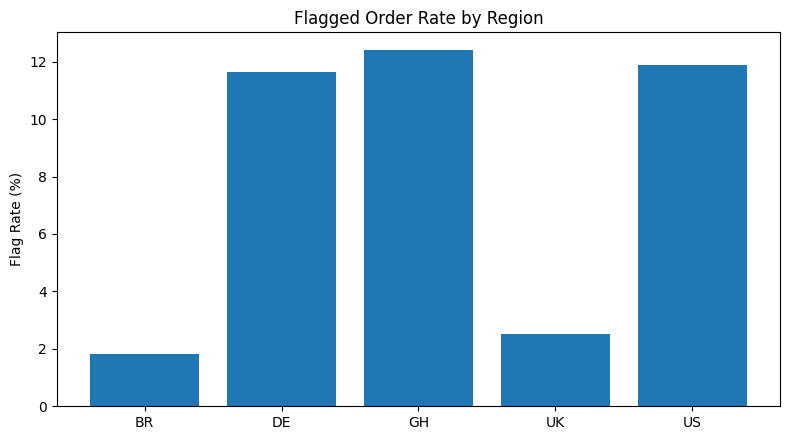

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(flag_summary.index, flag_summary['flag_rate_pct'])
ax.set_ylabel('Flag Rate (%)')
ax.set_title('Flagged Order Rate by Region')
plt.tight_layout()
plt.savefig('anomaly_flag_rate_by_region.png', dpi=120)
plt.show()

## Findings - fill this in with your actual numbers

_After running the cells above: what's the overall flag rate? Does one region flag noticeably more than others - and if so, is there an obvious explanation (e.g. a region with mostly one-time customers falling back to the noisier region-level baseline more often)? Do the top flagged orders look like genuine anomalies when you look at them, or like another data quirk? Write 2-3 sentences, then carry into `PROJECT_LOG.md`._

## Known limitations - worth stating explicitly
1. This flags unusual order **value** only - real fraud often looks perfectly normal in value but unusual in other ways (shipping address mismatch, rapid repeat attempts, stolen card patterns) that this dataset has no way to capture.
2. The z-score threshold (3) is a common statistical convention, not a business-validated cutoff - a real deployment would tune this against actual confirmed fraud cases, which don't exist in this dataset.
3. Orders using the region-level fallback (most customers, given how few are repeat buyers) are being compared against a noisier, less personalized baseline - flag results for these orders are less precise than for customers with enough history for their own baseline.

## Step 4 - Export results to SQL Server for Power BI

Exports only the flagged orders (not all 149K+ orders - Power BI doesn't need the full detail, just the cases worth reviewing),
plus the region-level flag-rate summary.

In [16]:
flagged_export = orders[orders['flagged']][['order_id', 'region', 'amount_usd', 'baseline', 'z_score']].copy()
flagged_export.to_sql('anomaly_flagged_orders', engine, schema='reporting', if_exists='replace', index=False)
print(f"Exported {len(flagged_export):,} flagged orders to reporting.anomaly_flagged_orders")

flag_summary_export = flag_summary.reset_index()
flag_summary_export.to_sql('anomaly_summary_by_region', engine, schema='reporting', if_exists='replace', index=False)
print(f"Exported {len(flag_summary_export):,} rows to reporting.anomaly_summary_by_region")

Exported 3,646 flagged orders to reporting.anomaly_flagged_orders
Exported 5 rows to reporting.anomaly_summary_by_region
